# HAT Clustering Analysis — Emotional vs Neutral

Each data point is one isolated inference trial. The server is reset, caches are dropped,
and a 2-second stabilisation baseline is observed before every trial.

**Data layout per trial** (`runs/<label>/p<NNNN>/`):
```
perf_stat.csv        — 1ms buckets, 24 perf events (HAT Layer 1 tracepoints + Layer 2 PMU/power)
hat_interrupts.csv   — 100ms: /proc/interrupts, /proc/softirqs, CPU freq per core
proc_sample.csv      — 100ms: system + per-process CPU jiffies, RSS
collector_meta.json  — t0_ns, duration, perf_events list
trial_meta.json      — prompt_index, label, ok, elapsed_ms
```

**Analysis pipeline:**
1. Load pre-extracted feature CSVs (one row per trial, one column per indicator×metric)
2. Confounder check: verify `elapsed_ms` is balanced between conditions
3. Feature selection: exclude artefact indicators and optionally length-confounded metrics
4. Univariate screening: Mann-Whitney U + Bonferroni correction per feature
5. Per-feature k=2 clustering (k-means + GMM) → composite ranking
6. Multi-feature GMM K-sweep on top-K features
7. PCA visualisation of cluster structure
8. Per-indicator × per-metric grid: finest-grained view of which (indicator, metric) pair drives separation
9. Test set evaluation with elapsed_ms residualisation


## 1 — Imports

In [2]:
import json, re, warnings
from pathlib import Path
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as sp_stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

print('Imports OK')


Imports OK


## 2 — Configuration

In [3]:
BASE_DIR = Path.home() / 'Desktop' / 'mccviahat'

print(f'BASE_DIR = {BASE_DIR}')
assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'


BASE_DIR = /Users/rsalvi/Desktop/mccviahat


## 3 — Load features

In [4]:
_node = 'clemsonc6420'
_data_dir = BASE_DIR / 'data' / _node
RUNS = ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC','1','2','3','4']

# ── Load token metadata once (optional) ──────────────────────────────────────
_token_csv = BASE_DIR / 'prompts' / '20base' / 'combined_token_counts.csv'
if _token_csv.exists():
    _tok_df = pd.read_csv(_token_csv)[['condition', 'prompt_index', 'n_tokens', 'title']]
else:
    _tok_df = None

# ── Load each run as its own DataFrame ───────────────────────────────────────
dfs_by_run = {}
loaded_files = []
for run in RUNS:
    csv_path = _data_dir / f'independent{run}.csv'
    assert csv_path.exists(), (
        f'{csv_path.name} not found at {csv_path}\n'
        'Run: python scripts/run/extract_features.py'
    )

    run_df = pd.read_csv(csv_path)
    run_df['run'] = run

    if _tok_df is not None:
        run_df = run_df.merge(_tok_df, on=['condition', 'prompt_index'], how='left')
    else:
        run_df['n_tokens'] = np.nan

    dfs_by_run[run] = run_df
    loaded_files.append(csv_path)

# Combined view (kept for backward compatibility with existing cells)
df_all = pd.concat([dfs_by_run[r] for r in RUNS], ignore_index=True)

# ── Results directory ────────────────────────────────────────────────
RESULTS_DIR = BASE_DIR / 'results' / 'independentABDEF'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results → {RESULTS_DIR}')

if _tok_df is not None:
    _missing = df_all['n_tokens'].isna().sum()
    print(f'  Joined n_tokens from {_token_csv.name}  '
          f'(matched {len(df_all) - _missing}/{len(df_all)} trials'
          + (f', {_missing} unmatched' if _missing else '') + ')')
else:
    print(f'  ⚠  Token counts not found at {_token_csv}')

print('Loaded files:')
for path in loaded_files:
    print(f'  - {path.name}')

print(f'Loaded {len(loaded_files)} runs, {len(df_all)} trials total')
print(f'  neutral: {(df_all.condition == "neutral").sum()}  |  emotional: {(df_all.condition == "emotional").sum()}')
print(f'  Run counts: {df_all["run"].value_counts().sort_index().to_dict()}')
print(f'  Feature columns: {len([c for c in df_all.columns if "__" in c])}')
print(f'Per-run DataFrames available: {list(dfs_by_run.keys())}')


Results → /Users/rsalvi/Desktop/mccviahat/results/independentABDEF
  ⚠  Token counts not found at /Users/rsalvi/Desktop/mccviahat/prompts/20base/combined_token_counts.csv
Loaded files:
  - independentA.csv
  - independentB.csv
  - independentD.csv
  - independentE.csv
  - independentF.csv
  - independentAA.csv
  - independentAB.csv
  - independentAC.csv
  - independent1.csv
  - independent2.csv
  - independent3.csv
  - independent4.csv
Loaded 12 runs, 480 trials total
  neutral: 240  |  emotional: 240
  Run counts: {'1': 40, '2': 40, '3': 40, '4': 40, 'A': 40, 'AA': 40, 'AB': 40, 'AC': 40, 'B': 40, 'D': 40, 'E': 40, 'F': 40}
  Feature columns: 580
Per-run DataFrames available: ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']


## 4 — Confounder check: elapsed_ms and n_tokens

If `elapsed_ms` or `n_tokens` (prompt token count) differs significantly between
conditions, any metric that scales with duration or input length is a confounder
rather than a true substrate signal. We check both and set the `LENGTH_CONFOUNDED`
flag used downstream.


In [5]:
from scipy import stats as sp_stats

# ── elapsed_ms ────────────────────────────────────────────────────────────────
# Ensure numeric (the CSV may store elapsed_ms as strings)
df_all['elapsed_ms'] = pd.to_numeric(df_all['elapsed_ms'], errors='coerce')

dur_n = df_all.loc[df_all.condition == 'neutral',   'elapsed_ms'].dropna().values
dur_e = df_all.loc[df_all.condition == 'emotional', 'elapsed_ms'].dropna().values

stat, p_len = sp_stats.mannwhitneyu(dur_n, dur_e, alternative='two-sided')

print(f'Neutral   elapsed_ms:  mean={dur_n.mean():.0f} ms, median={np.median(dur_n):.0f} ms, n={len(dur_n)}')
print(f'Emotional elapsed_ms:  mean={dur_e.mean():.0f} ms, median={np.median(dur_e):.0f} ms, n={len(dur_e)}')
print(f'Mann-Whitney U={stat:.0f},  p={p_len:.4g}')
if p_len < 0.05:
    print('⚠  elapsed_ms differs significantly between conditions (p < 0.05).')
    print('   Metrics that scale with duration may be confounded by prompt length.')
else:
    print('✓  No significant difference in elapsed_ms between conditions.')

# ── n_tokens ──────────────────────────────────────────────────────────────────
print()
if df_all['n_tokens'].notna().any():
    tok_n = df_all.loc[df_all.condition == 'neutral',   'n_tokens'].dropna().values
    tok_e = df_all.loc[df_all.condition == 'emotional', 'n_tokens'].dropna().values
    stat_t, p_tok = sp_stats.mannwhitneyu(tok_n, tok_e, alternative='two-sided')
    print(f'Neutral   n_tokens:    mean={tok_n.mean():.0f},  median={np.median(tok_n):.0f},  n={len(tok_n)}')
    print(f'Emotional n_tokens:    mean={tok_e.mean():.0f},  median={np.median(tok_e):.0f},  n={len(tok_e)}')
    print(f'Mann-Whitney U={stat_t:.0f},  p={p_tok:.4g}')
    if p_tok < 0.05:
        print('⚠  n_tokens differs significantly between conditions (p < 0.05).')
        print('   Metrics that scale with input length may also be confounded.')
    else:
        print('✓  No significant difference in n_tokens between conditions.')
else:
    p_tok = np.nan
    print('n_tokens: not available — run:')
    print('  python scripts/run/token_count_csv.py \\')
    print('    prompts/20base/independentE.json prompts/20base/independentN.json')

LENGTH_CONFOUNDED = p_len < 0.05
print(f'\nLength confound flag (elapsed_ms): LENGTH_CONFOUNDED = {LENGTH_CONFOUNDED}')

# Shared bin edges for the elapsed_ms histogram below
all_dur = np.concatenate([dur_n, dur_e])
bins = np.linspace(all_dur.min(), all_dur.max(), 30)

Neutral   elapsed_ms:  mean=22574 ms, median=22598 ms, n=240
Emotional elapsed_ms:  mean=22727 ms, median=22770 ms, n=240
Mann-Whitney U=26063,  p=0.07171
✓  No significant difference in elapsed_ms between conditions.

n_tokens: not available — run:
  python scripts/run/token_count_csv.py \
    prompts/20base/independentE.json prompts/20base/independentN.json

Length confound flag (elapsed_ms): LENGTH_CONFOUNDED = False


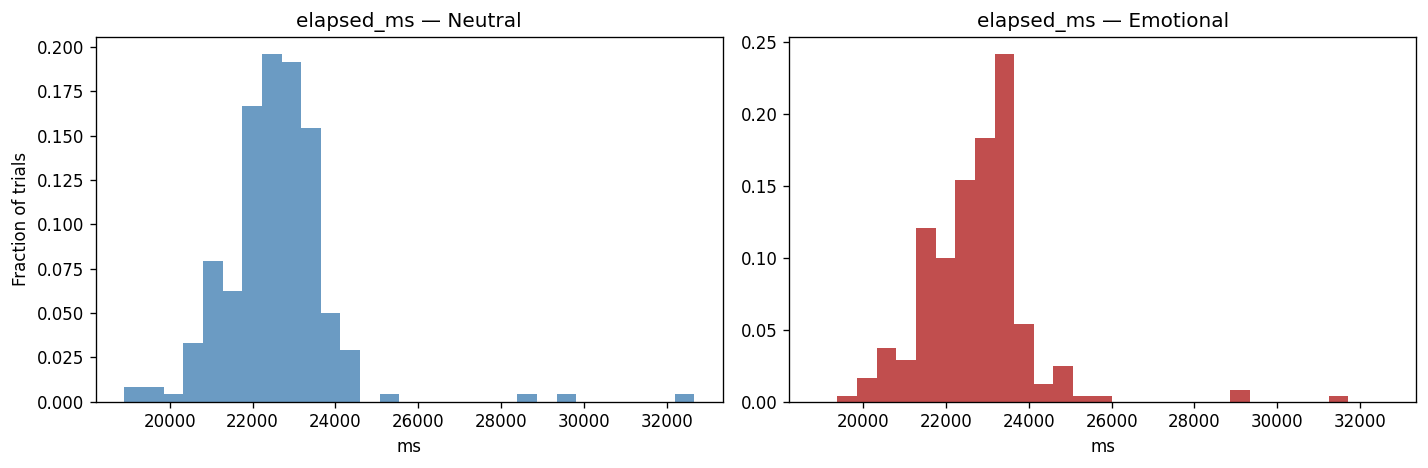


Length confound flag: LENGTH_CONFOUNDED = False
Note: mean_rate is normalised by dur_s — NOT confounded by length.
Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.


In [6]:
weights_n = np.ones(len(dur_n)) / len(dur_n)
weights_e = np.ones(len(dur_e)) / len(dur_e)

has_tokens = df_all['n_tokens'].notna().any()
n_panels = 4 if has_tokens else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4))

axes[0].hist(dur_n, bins=bins, weights=weights_n, color='steelblue', alpha=0.8, label='neutral')
axes[0].set_title('elapsed_ms — Neutral')
axes[0].set_xlabel('ms'); axes[0].set_ylabel('Fraction of trials')

axes[1].hist(dur_e, bins=bins, weights=weights_e, color='firebrick', alpha=0.8, label='emotional')
axes[1].set_title('elapsed_ms — Emotional')
axes[1].set_xlabel('ms')

if has_tokens:
    tok_bins = np.linspace(df_all['n_tokens'].min(), df_all['n_tokens'].max(), 20)
    w_tn = np.ones(len(tok_n)) / len(tok_n)
    w_te = np.ones(len(tok_e)) / len(tok_e)
    axes[2].hist(tok_n, bins=tok_bins, weights=w_tn, color='steelblue', alpha=0.8)
    axes[2].set_title('n_tokens — Neutral')
    axes[2].set_xlabel('tokens'); axes[2].set_ylabel('Fraction of trials')
    axes[3].hist(tok_e, bins=tok_bins, weights=w_te, color='firebrick', alpha=0.8)
    axes[3].set_title('n_tokens — Emotional')
    axes[3].set_xlabel('tokens')

plt.tight_layout()
plt.show()

print(f'\nLength confound flag: LENGTH_CONFOUNDED = {LENGTH_CONFOUNDED}')
print('Note: mean_rate is normalised by dur_s — NOT confounded by length.')
print('Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.')
if has_tokens:
    print(f'n_tokens confounder: p={p_tok:.4g}  '
          + ('⚠ significant' if p_tok < 0.05 else '✓ not significant'))


## 5 — Feature selection

Three filtering steps are applied in sequence:

1. **Length-confounded metrics** — if `LENGTH_CONFOUNDED=True`, optionally exclude metrics
   not normalised by duration (`variance`, `p90_p10`, `lz_complexity`, `perm_entropy`, `spectral_entropy`).
2. **Artefact / noise indicators** — hard-exclude indicators that are measurement artefacts
   or pure OS noise unrelated to inference (`hat_PMI`, `hat_NMI`, `hat_LOC`, `hat_RES`,
   `hat_CAL`, `hat_MCP`, `cpu_freq`).
3. **Correlation pruning** — for each pair with |Pearson r| > 0.95, drop the lower-variance one.


In [7]:
# --- Feature selection: include/exclude length-confounded features ---
from typing import List

# List of metrics that may be length-confounded
LENGTH_CONFOUNDED_METRICS = {
    'variance', 'p90_p10', 'lz_complexity', 'perm_entropy', 'spectral_entropy'
}

feature_cols = [c for c in df_all.columns if '__' in c]

def metric_of(col: str) -> str:
    # evt__metric
    return col.split('__', 1)[1]

length_confounded_cols   = [c for c in feature_cols if metric_of(c) in LENGTH_CONFOUNDED_METRICS]
length_unconfounded_cols = [c for c in feature_cols if metric_of(c) not in LENGTH_CONFOUNDED_METRICS]

print(f"Length-confounded features: {len(length_confounded_cols)}")
print(f"Length-unconfounded features: {len(length_unconfounded_cols)}")

# User selection: set to True to include, False to exclude length-confounded features
INCLUDE_LENGTH_CONFOUNDED = True  # <-- change this to True to include them

if INCLUDE_LENGTH_CONFOUNDED:
    selected_cols = length_unconfounded_cols + length_confounded_cols
    print("Including ALL features (length-confounded and unconfounded).")
else:
    selected_cols = length_unconfounded_cols
    print("Excluding length-confounded features.")

# Subset the feature matrix for downstream analysis
X = df_all[selected_cols].copy()
print(f"Final feature matrix shape: {X.shape}")

Length-confounded features: 290
Length-unconfounded features: 290
Including ALL features (length-confounded and unconfounded).
Final feature matrix shape: (480, 580)


### Build and clean feature matrix

In [8]:
# --- Build feature matrix and clean ---
# Use selected_cols from previous cell (already filtered for confounding)

# n_tokens and title are metadata/confounders — exclude from feature matrix
META_COLS = {'condition', 'prompt_index', 'elapsed_ms', 'dur_s', 'n_tokens', 'title'}
feat_cols = [c for c in X.columns if c not in META_COLS]

X_raw = X[feat_cols].apply(pd.to_numeric, errors='coerce')
y = (df_all['condition'] == 'emotional').astype(int).values  # 0=neutral, 1=emotional

# Drop zero-variance columns and fill NaN
X_raw = X_raw.loc[:, X_raw.std() > 0]
X_raw = X_raw.fillna(X_raw.median())

feat_cols = list(X_raw.columns)
print(f'Feature matrix: {X_raw.shape[0]} samples × {X_raw.shape[1]} features')

# Standardise
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)
print('Standardised.')

Feature matrix: 480 samples × 386 features
Standardised.


In [9]:
# ── Signal-quality mask ─────────────────────────────────────────────────────
# Based on the physiological interpretation of each hardware/OS counter.
# Indicators are the prefix before '__' in column names (e.g. hat_TLB, cache-misses).
#
# Tier 1 — Primary computation-coupled signals (direct inference substrate signals)
PRIMARY_SIGNALS = {
    'tlb:tlb_flush',          # hardware TLB shootdown — direct VM pressure
    'LLC-load-misses',        # DRAM fetches from model weight access
    'cache-misses',           # L1/L2 cache pressure from inference
    'cache-references',       # L1/L2 cache references
    'dTLB-load-misses',       # data TLB misses during weight tensor loads
    'branch-misses',          # branch predictor misses shaped by inference control flow
    'branch-instructions',    # total branch count
    'instructions',           # raw computational throughput
    'cycles',                 # CPU cycle count
    'core_power.throttle',    # thermal throttle from sustained inference load
}

# Tier 2 — Computation-coupled but indirect (keep, interpret with caveats)
INDIRECT_SIGNALS = {
    'power/energy-pkg/',      # RAPL package energy
    'power/energy-ram/',      # RAPL RAM energy
    'msr/cpu_thermal_margin/',# thermal margin (slow-moving, session-level)
    'irq:irq_handler_exit',   # all IRQ completions — inference-coupled but noisy
    'irq:softirq_raise',      # softirq scheduling — computation-coupled, aggregated
}

# Tier 3 — Confounder controls (keep but do NOT interpret as substrate signals)
CONFOUNDER_CONTROLS = {
    'context-switches',       # scheduling artefact; if differs, explains hw counter diffs
    'cpu-migrations',         # scheduling/migration artefact
    'page-faults',            # mmap weight access (minor) + noise (major)
    'cpu-clock',              # duration normaliser
}

# Tier 4 — HAT substrate signals (hat__ prefix indicators to keep)
HAT_PRIMARY = {
    'hat_TLB',   # TLB shootdown IPIs — direct VM pressure from inference
    'hat_BLOCK', # block I/O softirq — memory pressure / page reclaim during weight access
    'hat_IWI',   # interprocessor wakeup IRQs — NUMA memory access patterns
}

# Tier 5 — HAT scheduling-coupled (keep with caveats)
HAT_SCHEDULING = {
    'hat_NET_RX',  # scheduler side-effect of CPU occupancy
    'hat_NET_TX',
    'hat_SCHED',   # scheduler softirq — modulated by inference CPU demand
    'hat_RCU',     # RCU callbacks — loosely correlated with kernel activity
    'hat_TIMER',   # timer softirq — partially fixed-rate, partially load-dependent
}

# Exclude — measurement artefact or pure OS noise unrelated to inference
EXCLUDE_INDICATORS = {
    'hat_PMI',   # perf's own sampling interrupts — artefact, not inference-related
    'hat_NMI',   # non-maskable interrupt counts — hardware artefact
    'hat_LOC',   # local APIC timer — fires at fixed kernel tick rate, ignores inference
    'hat_RES',   # rescheduling IPIs — scheduler load balancing, not inference
    'hat_CAL',   # function-call IPIs — OS housekeeping
    'hat_MCP',   # machine check polls — periodic kernel health, not inference-driven
    'cpu_freq',  # DVFS governor — consequence of power policy, not a substrate signal
}

def _indicator_of(col: str) -> str:
    """Return the indicator prefix of a column named 'indicator__metric'."""
    return col.split('__', 1)[0]

_before = len(feat_cols)
feat_cols = [
    c for c in feat_cols
    if _indicator_of(c) not in EXCLUDE_INDICATORS
]
_excluded = _before - len(feat_cols)

X_raw = X_raw[feat_cols].copy()
X     = X[feat_cols].copy()

print(f'Signal-quality mask:')
print(f'  Excluded {_excluded} columns from {_before} '
      f'({", ".join(sorted(EXCLUDE_INDICATORS))})')
print(f'  Remaining: {len(feat_cols)} features')


Signal-quality mask:
  Excluded 54 columns from 386 (cpu_freq, hat_CAL, hat_LOC, hat_MCP, hat_NMI, hat_PMI, hat_RES)
  Remaining: 332 features


In [10]:

"""# ── Correlation pruning ──────────────────────────────────────────────
# For each pair of features with |Pearson r| > 0.95, drop the one with
# lower variance (less informative), keeping the more variable one.
CORR_THRESHOLD = 0.95

corr_matrix = X_raw.corr().abs()
# Upper triangle only (avoid double-counting pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
)

# For each column, collect all its partners that exceed threshold
# Sort features by variance descending so we always keep the most variable
feat_var = X_raw.var().sort_values(ascending=False)
ordered  = feat_var.index.tolist()   # high-variance features first

to_drop = set()
for feat in ordered:
    if feat in to_drop:
        continue
    # Partners with correlation > threshold that haven't been dropped yet
    partners = upper.index[upper[feat] > CORR_THRESHOLD].tolist() if feat in upper.columns else []
    for partner in partners:
        if partner not in to_drop:
            # Drop the lower-variance one (partner comes later in `ordered`)
            to_drop.add(partner)

X_raw    = X_raw.drop(columns=list(to_drop))
feat_cols = list(X_raw.columns)

# Re-standardise after pruning
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)

print(f'Correlation pruning (|r| > {CORR_THRESHOLD}):')
print(f'  Dropped : {len(to_drop)} features')
print(f'  Kept    : {len(feat_cols)} features')"""


"# ── Correlation pruning ──────────────────────────────────────────────\n# For each pair of features with |Pearson r| > 0.95, drop the one with\n# lower variance (less informative), keeping the more variable one.\nCORR_THRESHOLD = 0.95\n\ncorr_matrix = X_raw.corr().abs()\n# Upper triangle only (avoid double-counting pairs)\nupper = corr_matrix.where(\n    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)\n)\n\n# For each column, collect all its partners that exceed threshold\n# Sort features by variance descending so we always keep the most variable\nfeat_var = X_raw.var().sort_values(ascending=False)\nordered  = feat_var.index.tolist()   # high-variance features first\n\nto_drop = set()\nfor feat in ordered:\n    if feat in to_drop:\n        continue\n    # Partners with correlation > threshold that haven't been dropped yet\n    partners = upper.index[upper[feat] > CORR_THRESHOLD].tolist() if feat in upper.columns else []\n    for partner in partners:\n        if partner not in to

In [11]:
# --- Diagnostics: Check feature selection logic ---
print(f"INCLUDE_LENGTH_CONFOUNDED = {INCLUDE_LENGTH_CONFOUNDED}")
print(f"Length-confounded features matched: {len(length_confounded_cols)}")
print(f"Length-unconfounded features matched: {len(length_unconfounded_cols)}")
print(f"Selected columns: {len(selected_cols)}")
print(f"Final feature matrix shape after cleaning: {X.shape}")

INCLUDE_LENGTH_CONFOUNDED = True
Length-confounded features matched: 290
Length-unconfounded features matched: 290
Selected columns: 580
Final feature matrix shape after cleaning: (480, 332)


## 5b — HAT Layer 1 audit: are genuine hardware anomalies present?

The HAT definition names six specific interrupt types as **Layer 1** signals —
the genuine hardware anomaly events, distinct from continuous performance counters.

| Indicator | What it counts | Expected on healthy node |
|---|---|---|
| `hat_SPU` | Spurious interrupts — APIC noise, no real source | ~0 |
| `hat_MCE` | Machine Check Exceptions — hardware fault detected | 0 |
| `hat_TLB` | TLB Shootdown IPIs — VM pressure from inference | **may have signal** |
| `hat_MCP` | Machine Check Polls — periodic kernel health scan | 0 (excluded as artefact) |

The question is simple: **do any of these fire during inference, and if so,
does the rate differ between neutral and emotional prompts?**

We also include three **Layer 2** reference indicators (continuous PMU metrics
known to carry signal) so you can compare the scale of any L1 signal against
signals we already know discriminate between conditions.

In [12]:
# ── §5b Setup ────────────────────────────────────────────────────────────────
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# HAT Layer 1 indicators — from /proc/interrupts (separate named rows)
HAT_L1 = ['hat_SPU', 'hat_MCE', 'hat_TLB']
# hat_PMI and hat_MCP are already excluded by the signal-quality mask above

# Layer 2 reference (known discriminators, shown for comparison)
HAT_L2_REF = ['dTLB-load-misses', 'cache-misses', 'cache-references']

ALL_FOCUS  = HAT_L1 + HAT_L2_REF

ALL_METRICS = [
    'mean_rate', 'variance', 'p90_p10', 'slope',
    'spectral_entropy', 'iat_cv', 'burst_rate',
    'burst_clustering', 'lz_complexity', 'perm_entropy'
]
'''ALL_METRICS = [
    'mean_rate',  'slope',
   'iat_cv', 'burst_rate',
    'burst_clustering', 
]'''


# Helper: run MWU on two series, return (p, direction, cohen_d)
def mwu_stats(n_vals, e_vals):
    if len(n_vals) < 3 or len(e_vals) < 3:
        return float('nan'), '—', float('nan')
    _, p = mannwhitneyu(n_vals, e_vals, alternative='two-sided')
    direction = '↑E' if e_vals.mean() > n_vals.mean() else '↓E'
    pooled = np.concatenate([n_vals.values, e_vals.values])
    d = (e_vals.mean() - n_vals.mean()) / pooled.std(ddof=1) if pooled.std(ddof=1) > 0 else 0.0
    return p, direction, d

# Helper: get vals for (df, col, condition)
def get_vals(df, col, cond):
    return pd.to_numeric(df.loc[df.condition == cond, col], errors='coerce').dropna()

# Helper: check if a column is all-zero
def is_all_zero(df, col):
    vals = pd.to_numeric(df[col], errors='coerce').dropna()
    return (vals.abs() < 1e-9).all()

print('Setup complete.')
print(f'HAT L1 indicators: {HAT_L1}')
print(f'HAT L2 reference:  {HAT_L2_REF}')
print(f'Metrics to test:   {ALL_METRICS}')
print(f'Total trials:      {len(df_all)}  (neutral: {(df_all.condition=="neutral").sum()}, '
      f'emotional: {(df_all.condition=="emotional").sum()})')


Setup complete.
HAT L1 indicators: ['hat_SPU', 'hat_MCE', 'hat_TLB']
HAT L2 reference:  ['dTLB-load-misses', 'cache-misses', 'cache-references']
Metrics to test:   ['mean_rate', 'variance', 'p90_p10', 'slope', 'spectral_entropy', 'iat_cv', 'burst_rate', 'burst_clustering', 'lz_complexity', 'perm_entropy']
Total trials:      480  (neutral: 240, emotional: 240)


### 5b-1 — Availability and zero-check (all runs combined)

Before any statistics, we check which indicators are even present in the data
and whether they contain any non-zero values. An all-zero column means the event
never fired across 200 trials — a direct confirmation of node health.

In [13]:
# ── Availability check across all runs combined ───────────────────────────────
print(f"{'Layer':<5} {'Indicator':<28} {'Metric':<22} {'In data?':>8}  "
      f"{'Non-zero trials':>16}  {'Status':>12}")
print('-' * 100)

availability = {}   # ind -> {metric -> {present, nonzero_count, total}}

for ind in ALL_FOCUS:
    layer = 'L1' if ind in HAT_L1 else 'L2'
    availability[ind] = {}
    first = True
    for metric in ALL_METRICS:
        col = f"{ind}__{metric}"
        present = col in df_all.columns
        if present:
            vals = pd.to_numeric(df_all[col], errors='coerce').dropna()
            nz = (vals.abs() > 1e-9).sum()
            total = len(vals)
            status = 'ALL ZERO' if nz == 0 else ('SPARSE' if nz < 10 else 'HAS SIGNAL')
        else:
            nz, total, status = 0, 0, 'MISSING'
        availability[ind][metric] = {'present': present, 'nz': nz, 'total': total, 'status': status}
        ind_label = ind if first else ''
        layer_label = layer if first else ''
        print(f"  {layer_label:<4} {ind_label:<28} {metric:<22} {'YES' if present else 'NO':>8}  "
              f"{f'{nz}/{total}' if present else '—':>16}  {status:>12}")
        first = False
    print()


Layer Indicator                    Metric                 In data?   Non-zero trials        Status
----------------------------------------------------------------------------------------------------
  L1   hat_SPU                      mean_rate                   YES             0/480      ALL ZERO
                                    variance                    YES             0/480      ALL ZERO
                                    p90_p10                     YES             0/480      ALL ZERO
                                    slope                       YES             0/480      ALL ZERO
                                    spectral_entropy            YES             0/480      ALL ZERO
                                    iat_cv                      YES               0/0      ALL ZERO
                                    burst_rate                  YES             0/480      ALL ZERO
                                    burst_clustering            YES             0/480      ALL ZERO


### 5b-2 — Per-run availability and data point counts

How many neutral and emotional trials contributed to each indicator in each run.
This matters because an indicator missing from some runs changes the effective sample size.

In [14]:
# ── Per-run data point count table ───────────────────────────────────────────
print(f"{'Indicator':<28}  " + '  '.join(f"Run {r} (N/E)" for r in RUNS))
print('-' * 100)

for ind in ALL_FOCUS:
    layer = 'L1' if ind in HAT_L1 else 'L2'
    col = f"{ind}__mean_rate"   # use mean_rate as proxy for presence
    row_parts = []
    for run in RUNS:
        df_r = dfs_by_run[run]
        if col not in df_r.columns:
            row_parts.append('missing')
            continue
        n_n = (df_r.condition == 'neutral').sum()
        n_e = (df_r.condition == 'emotional').sum()
        zero = is_all_zero(df_r, col)
        tag = ' (0)' if zero else ''
        row_parts.append(f"{n_n}/{n_e}{tag}")
    print(f"  [{layer}] {ind:<26}  " + '  '.join(f"{p:>12}" for p in row_parts))


Indicator                     Run A (N/E)  Run B (N/E)  Run D (N/E)  Run E (N/E)  Run F (N/E)  Run AA (N/E)  Run AB (N/E)  Run AC (N/E)  Run 1 (N/E)  Run 2 (N/E)  Run 3 (N/E)  Run 4 (N/E)
----------------------------------------------------------------------------------------------------
  [L1] hat_SPU                        20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)
  [L1] hat_MCE                        20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)     20/20 (0)
  [L1] hat_TLB                            20/20         20/20         20/20         20/20         20/20         20/20         20/20         20/20         20/20         20/20         20/20         20/20
  [L2] dTLB-load-misses                   20/20         20/20         20/20         20/20         20/20  

### 5b-3 — Full indicator × metric MWU table (all runs combined, n=200)

For every (indicator, metric) pair we run MWU on all 200 trials pooled.
Pooling all runs gives the most statistical power but hides run-to-run variability
(covered in §5b-5). Significant cells are marked ★.

In [15]:
# ── Full indicator × metric MWU — all runs combined ──────────────────────────
rows = []
for ind in ALL_FOCUS:
    layer = 'L1' if ind in HAT_L1 else 'L2'
    for metric in ALL_METRICS:
        col = f"{ind}__{metric}"
        if col not in df_all.columns:
            rows.append({'indicator': ind, 'layer': layer, 'metric': metric,
                         'status': 'missing', 'p': float('nan'),
                         'direction': '—', 'd': float('nan'),
                         'n_mean': float('nan'), 'e_mean': float('nan')})
            continue
        n_vals = get_vals(df_all, col, 'neutral')
        e_vals = get_vals(df_all, col, 'emotional')
        if is_all_zero(df_all, col):
            rows.append({'indicator': ind, 'layer': layer, 'metric': metric,
                         'status': 'all_zero', 'p': float('nan'),
                         'direction': '—', 'd': float('nan'),
                         'n_mean': 0.0, 'e_mean': 0.0})
            continue
        p, direction, d = mwu_stats(n_vals, e_vals)
        rows.append({'indicator': ind, 'layer': layer, 'metric': metric,
                     'status': 'ok', 'p': p, 'direction': direction, 'd': d,
                     'n_mean': n_vals.mean(), 'e_mean': e_vals.mean()})

grid_df = pd.DataFrame(rows)

# Print table
print(f"{'Layer':<4} {'Indicator':<28} {'Metric':<22} {'N mean':>12}  {'E mean':>12}  "
      f"{'p-value':>10}  {'Dir':>4}  {'Cohen d':>8}  Note")
print('-' * 110)

prev_ind = None
for _, r in grid_df.iterrows():
    if r['indicator'] != prev_ind:
        print()
        prev_ind = r['indicator']
    if r['status'] == 'missing':
        print(f"  {r['layer']:<3} {r['indicator']:<28} {r['metric']:<22} {'—':>12}  {'—':>12}  {'—':>10}  {'—':>4}  {'—':>8}  MISSING")
        continue
    if r['status'] == 'all_zero':
        print(f"  {r['layer']:<3} {r['indicator']:<28} {r['metric']:<22} {'0':>12}  {'0':>12}  {'—':>10}  {'—':>4}  {'—':>8}  ALL ZERO")
        continue
    star = '★' if r['p'] < 0.05 else ''
    bonf = ' BONF★' if r['p'] < 0.05/len(grid_df) else ''
    print(f"  {r['layer']:<3} {r['indicator']:<28} {r['metric']:<22} "
          f"{r['n_mean']:>12.4g}  {r['e_mean']:>12.4g}  "
          f"{r['p']:>10.4f}  {r['direction']:>4}  {r['d']:>8.3f}  {star}{bonf}")

# Summary counts
sig = grid_df[(grid_df.status == 'ok') & (grid_df.p < 0.05)]
print(f"\nTotal (indicator, metric) pairs tested: {(grid_df.status=='ok').sum()}")
print(f"Significant at p<0.05: {len(sig)}")
print(f"Significant after Bonferroni ({0.05/max((grid_df.status=='ok').sum(),1):.2e}): "
      f"{(grid_df[(grid_df.status=='ok')].p < 0.05/(grid_df.status=='ok').sum()).sum()}")


Layer Indicator                    Metric                       N mean        E mean     p-value   Dir   Cohen d  Note
--------------------------------------------------------------------------------------------------------------

  L1  hat_SPU                      mean_rate                         0             0           —     —         —  ALL ZERO
  L1  hat_SPU                      variance                          0             0           —     —         —  ALL ZERO
  L1  hat_SPU                      p90_p10                           0             0           —     —         —  ALL ZERO
  L1  hat_SPU                      slope                             0             0           —     —         —  ALL ZERO
  L1  hat_SPU                      spectral_entropy                  0             0           —     —         —  ALL ZERO
  L1  hat_SPU                      iat_cv                            0             0           —     —         —  ALL ZERO
  L1  hat_SPU                  

### 5b-4 — Heatmap: indicator × metric significance (all runs combined)

Each cell shows −log₁₀(p). Darker = more significant.
Grey cells are all-zero (healthy node, no anomaly events).
Direction arrows (↑E / ↓E) and ★ for p < 0.05 annotate each cell.

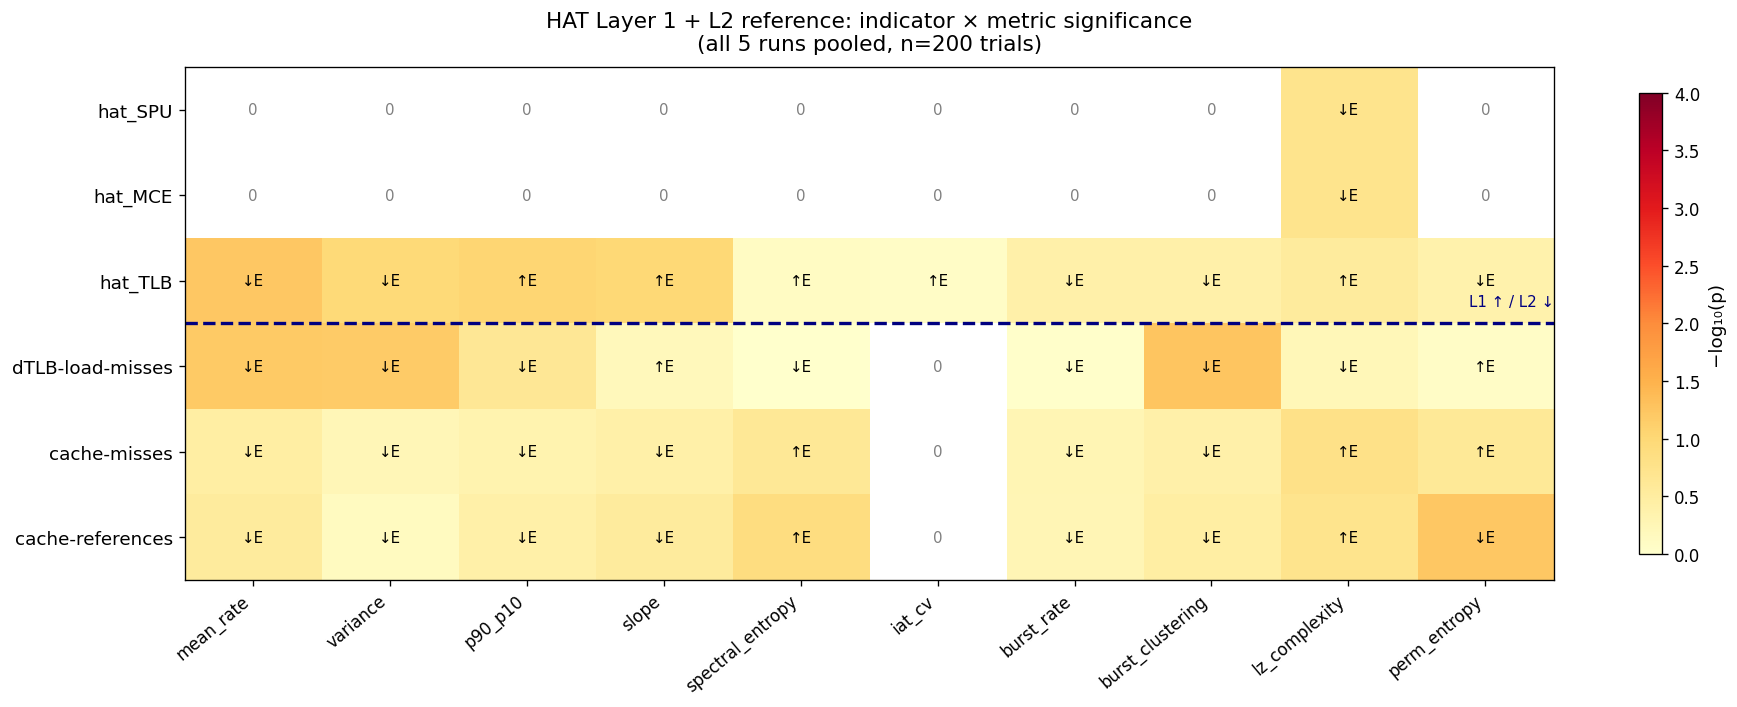

In [16]:
# ── Heatmap: indicator × metric, all runs combined ───────────────────────────
pivot = grid_df.pivot(index='indicator', columns='metric', values='p')
pivot = pivot.reindex(index=ALL_FOCUS, columns=ALL_METRICS)

dir_pivot = grid_df.pivot(index='indicator', columns='metric', values='direction')
dir_pivot = dir_pivot.reindex(index=ALL_FOCUS, columns=ALL_METRICS)

status_pivot = grid_df.pivot(index='indicator', columns='metric', values='status')
status_pivot = status_pivot.reindex(index=ALL_FOCUS, columns=ALL_METRICS)

log_p = -np.log10(np.clip(pivot.values.astype(float), 1e-10, 1.0))
log_p_masked = np.ma.masked_invalid(log_p)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(log_p_masked, aspect='auto', cmap='YlOrRd', vmin=0, vmax=4)

ax.set_xticks(range(len(ALL_METRICS)))
ax.set_xticklabels(ALL_METRICS, rotation=40, ha='right', fontsize=10)
ax.set_yticks(range(len(ALL_FOCUS)))
ax.set_yticklabels(ALL_FOCUS, fontsize=11)

# L1/L2 separator
ax.axhline(len(HAT_L1) - 0.5, color='navy', lw=2, ls='--')
ax.text(len(ALL_METRICS) - 0.5, len(HAT_L1) - 0.7,
        'L1 ↑ / L2 ↓', fontsize=9, ha='right', color='navy')

# Annotate cells
for i, ind in enumerate(ALL_FOCUS):
    for j, metric in enumerate(ALL_METRICS):
        s = status_pivot.loc[ind, metric]
        if s == 'all_zero':
            ax.text(j, i, '0', ha='center', va='center', fontsize=9, color='grey')
        elif s == 'ok':
            p_val = pivot.loc[ind, metric]
            d_val = dir_pivot.loc[ind, metric]
            star  = '★' if (pd.notna(p_val) and p_val < 0.05) else ''
            color = 'white' if (pd.notna(p_val) and -np.log10(p_val+1e-10) > 2) else 'black'
            ax.text(j, i, f"{d_val}{star}", ha='center', va='center',
                    fontsize=9, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label('−log₁₀(p)', fontsize=11)
plt.title('HAT Layer 1 + L2 reference: indicator × metric significance\n'
          '(all 5 runs pooled, n=200 trials)', fontsize=13, pad=10)
plt.tight_layout()
plt.show()


### 5b-5 — Per-run analysis: each indicator × all metrics

We now repeat the MWU analysis separately for each of the five runs (n=40 per run).
This answers: is the signal consistent across sessions, or is it run-specific?

For each run we print the full indicator × metric table and flag which cells
are significant. We also note how many data points each run contributes.

In [17]:
# ── Per-run full grid ─────────────────────────────────────────────────────────
all_run_grids = {}   # run -> DataFrame (same structure as grid_df)

for run in RUNS:
    df_r = dfs_by_run[run]
    n_total = len(df_r)
    n_n = (df_r.condition == 'neutral').sum()
    n_e = (df_r.condition == 'emotional').sum()

    print(f"{'='*80}")
    print(f"  RUN {run}  —  {n_total} trials  (neutral: {n_n}, emotional: {n_e})")
    print(f"{'='*80}")
    print(f"  {'Layer':<4} {'Indicator':<28} {'Metric':<22} {'N mean':>12}  "
          f"{'E mean':>12}  {'p-value':>10}  {'Dir':>4}  {'d':>7}  Note")
    print(f"  {'-'*108}")

    run_rows = []
    prev_ind = None
    for ind in ALL_FOCUS:
        layer = 'L1' if ind in HAT_L1 else 'L2'
        for metric in ALL_METRICS:
            col = f"{ind}__{metric}"
            if col not in df_r.columns:
                run_rows.append({'indicator': ind, 'layer': layer, 'metric': metric,
                                 'status': 'missing', 'p': float('nan'),
                                 'direction': '—', 'd': float('nan')})
                continue
            n_vals = get_vals(df_r, col, 'neutral')
            e_vals = get_vals(df_r, col, 'emotional')
            if is_all_zero(df_r, col):
                run_rows.append({'indicator': ind, 'layer': layer, 'metric': metric,
                                 'status': 'all_zero', 'p': float('nan'),
                                 'direction': '—', 'd': float('nan'),
                                 'n_n': len(n_vals), 'n_e': len(e_vals)})
                if ind != prev_ind:
                    print()
                    prev_ind = ind
                print(f"  {layer:<4} {ind:<28} {metric:<22} {'0':>12}  {'0':>12}  "
                      f"{'—':>10}  {'—':>4}  {'—':>7}  ALL ZERO")
                continue
            p, direction, d = mwu_stats(n_vals, e_vals)
            run_rows.append({'indicator': ind, 'layer': layer, 'metric': metric,
                             'status': 'ok', 'p': p, 'direction': direction, 'd': d,
                             'n_n': len(n_vals), 'n_e': len(e_vals)})
            if ind != prev_ind:
                print()
                prev_ind = ind
            star = '★' if p < 0.05 else ''
            print(f"  {layer:<4} {ind:<28} {metric:<22} "
                  f"{n_vals.mean():>12.4g}  {e_vals.mean():>12.4g}  "
                  f"{p:>10.4f}  {direction:>4}  {d:>7.3f}  {star}")

    run_grid = pd.DataFrame(run_rows)
    all_run_grids[run] = run_grid
    n_sig = (run_grid[(run_grid.status=='ok')].p < 0.05).sum()
    print(f"\n  → Significant cells (p<0.05): {n_sig} / "
          f"{(run_grid.status=='ok').sum()}")
    print()


  RUN A  —  40 trials  (neutral: 20, emotional: 20)
  Layer Indicator                    Metric                       N mean        E mean     p-value   Dir        d  Note
  ------------------------------------------------------------------------------------------------------------

  L1   hat_SPU                      mean_rate                         0             0           —     —        —  ALL ZERO
  L1   hat_SPU                      variance                          0             0           —     —        —  ALL ZERO
  L1   hat_SPU                      p90_p10                           0             0           —     —        —  ALL ZERO
  L1   hat_SPU                      slope                             0             0           —     —        —  ALL ZERO
  L1   hat_SPU                      spectral_entropy                  0             0           —     —        —  ALL ZERO
  L1   hat_SPU                      iat_cv                            0             0           —    

### 5b-6 — Per-run heatmaps

One heatmap per run. Lets you visually compare which (indicator, metric) pairs
light up in each session. Consistent colouring across all five panels = stable signal.

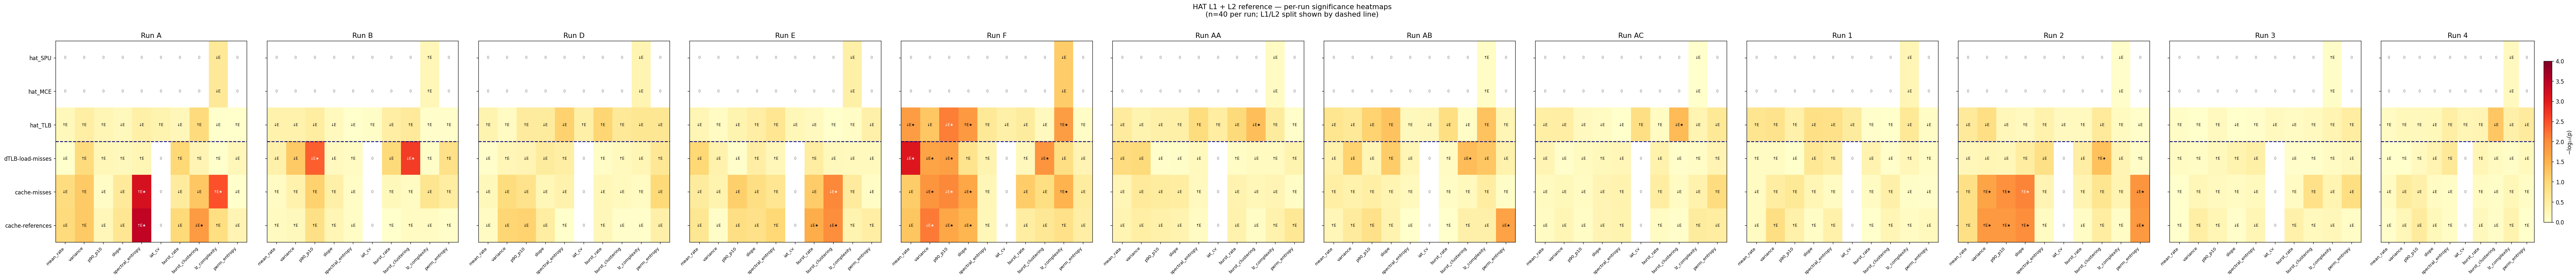

In [18]:
# ── Per-run heatmaps (5 panels) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, len(RUNS), figsize=(5.5 * len(RUNS), 7), sharey=True)

for ax, run in zip(axes, RUNS):
    run_grid = all_run_grids[run]
    pivot_r  = run_grid.pivot(index='indicator', columns='metric', values='p')
    pivot_r  = pivot_r.reindex(index=ALL_FOCUS, columns=ALL_METRICS)
    dir_r    = run_grid.pivot(index='indicator', columns='metric', values='direction')
    dir_r    = dir_r.reindex(index=ALL_FOCUS, columns=ALL_METRICS)
    stat_r   = run_grid.pivot(index='indicator', columns='metric', values='status')
    stat_r   = stat_r.reindex(index=ALL_FOCUS, columns=ALL_METRICS)

    lp = -np.log10(np.clip(pivot_r.values.astype(float), 1e-10, 1.0))
    lp_m = np.ma.masked_invalid(lp)

    im = ax.imshow(lp_m, aspect='auto', cmap='YlOrRd', vmin=0, vmax=4)
    ax.set_title(f'Run {run}', fontsize=13)
    ax.set_xticks(range(len(ALL_METRICS)))
    ax.set_xticklabels(ALL_METRICS, rotation=45, ha='right', fontsize=8)
    if ax == axes[0]:
        ax.set_yticks(range(len(ALL_FOCUS)))
        ax.set_yticklabels(ALL_FOCUS, fontsize=10)
    ax.axhline(len(HAT_L1) - 0.5, color='navy', lw=1.5, ls='--')

    for i, ind in enumerate(ALL_FOCUS):
        for j, metric in enumerate(ALL_METRICS):
            s = stat_r.loc[ind, metric] if ind in stat_r.index else 'missing'
            if s == 'all_zero':
                ax.text(j, i, '0', ha='center', va='center', fontsize=7, color='grey')
            elif s == 'ok':
                pv  = pivot_r.loc[ind, metric]
                dv  = dir_r.loc[ind, metric]
                star = '★' if (pd.notna(pv) and pv < 0.05) else ''
                color = 'white' if (pd.notna(pv) and -np.log10(pv+1e-10) > 2) else 'black'
                ax.text(j, i, f"{dv}{star}", ha='center', va='center',
                        fontsize=7, color=color)

cbar = fig.colorbar(im, ax=axes[-1], shrink=0.8)
cbar.set_label('−log₁₀(p)', fontsize=10)
plt.suptitle('HAT L1 + L2 reference — per-run significance heatmaps\n'
             '(n=40 per run; L1/L2 split shown by dashed line)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


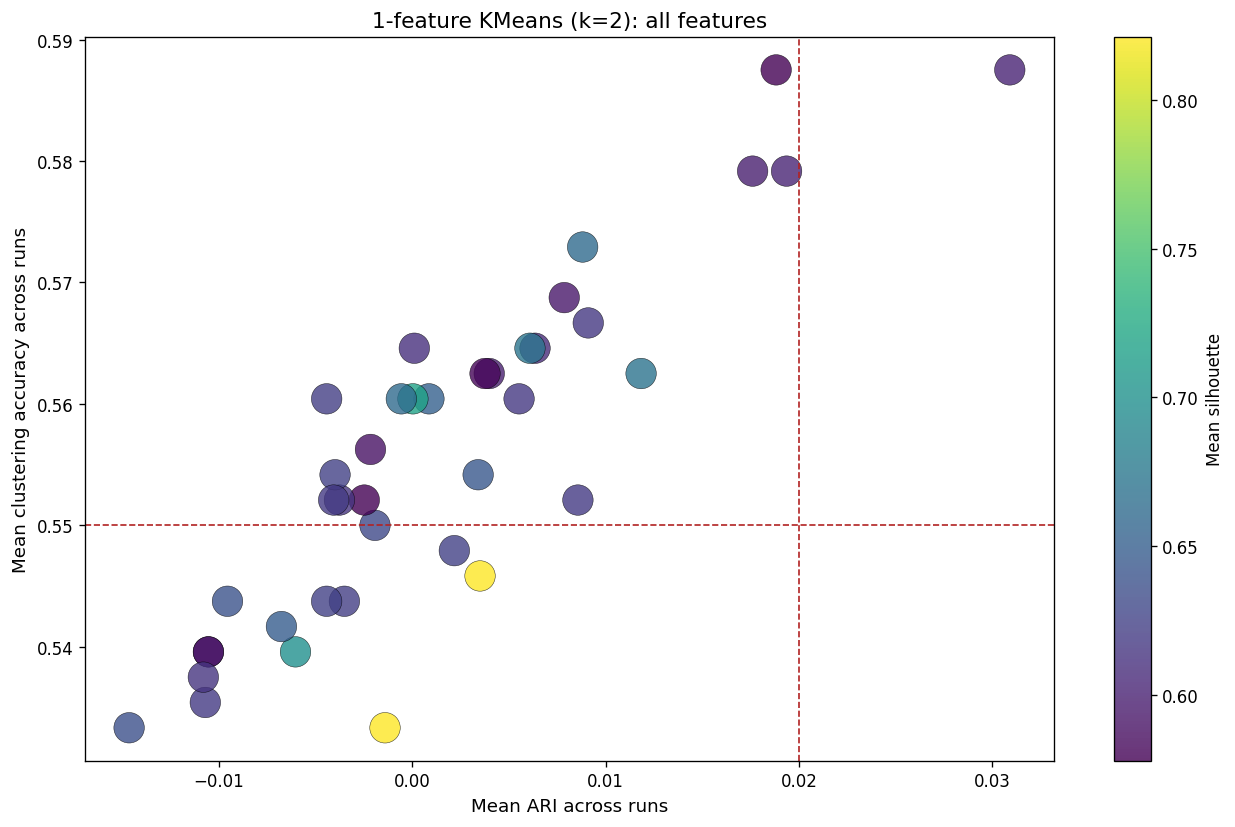

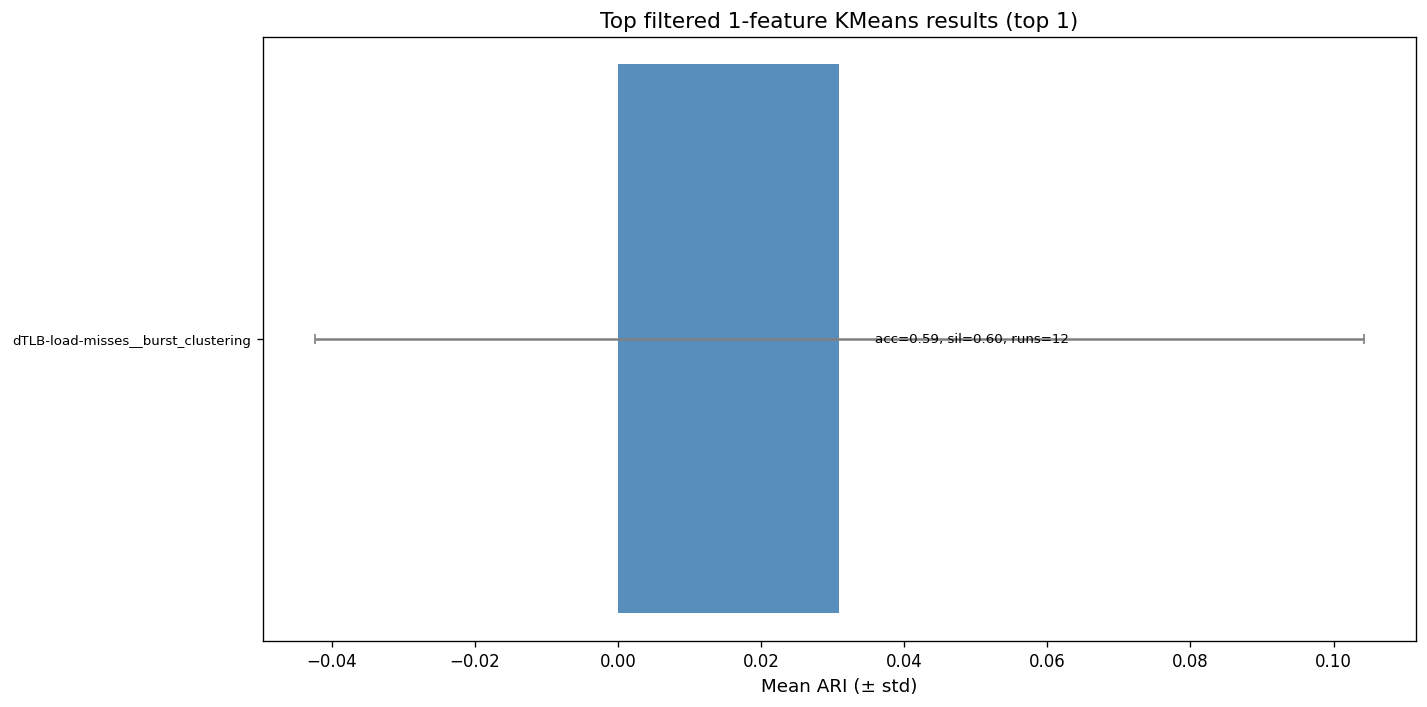

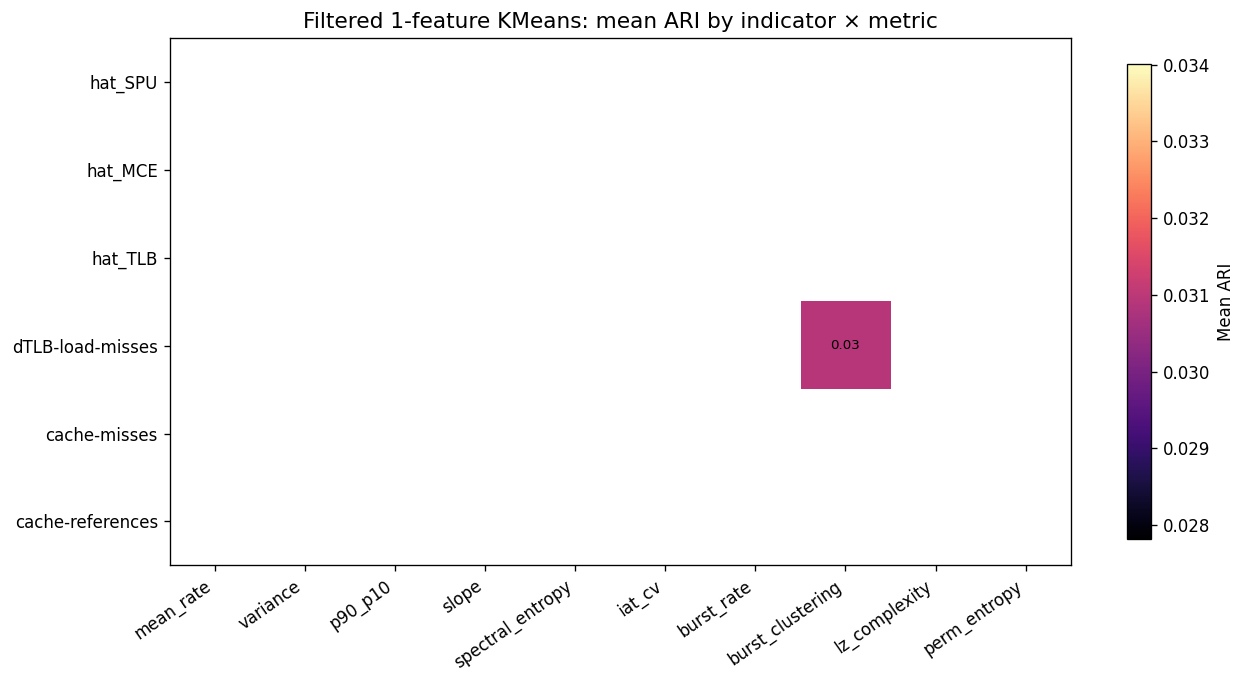

In [19]:
# ── 1-feature KMeans (k=2) across runs: plots + filters ──────────────────────
# Requires: RUNS, dfs_by_run, ALL_FOCUS, ALL_METRICS, KMeans, adjusted_rand_score

k1_rows = []

for run in RUNS:
    df_r = dfs_by_run[run].copy()
    y_r = (df_r['condition'] == 'emotional').astype(int).values

    for ind in ALL_FOCUS:
        for metric in ALL_METRICS:
            col = f"{ind}__{metric}"
            if col not in df_r.columns:
                continue

            x = pd.to_numeric(df_r[col], errors='coerce')
            mask = x.notna().values
            if mask.sum() < 8:
                continue

            x_use = x.values[mask]
            y_use = y_r[mask]
            if len(np.unique(y_use)) < 2:
                continue
            if np.nanstd(x_use) < 1e-12:
                continue

            x_std = ((x_use - np.mean(x_use)) / (np.std(x_use) + 1e-12)).reshape(-1, 1)

            km = KMeans(n_clusters=2, random_state=42, n_init=20)
            labels = km.fit_predict(x_std)

            acc_direct = (labels == y_use).mean()
            acc_flip = (1 - labels == y_use).mean()
            acc = float(max(acc_direct, acc_flip))
            ari = float(adjusted_rand_score(y_use, labels))

            if len(np.unique(labels)) == 2 and len(x_std) > 2:
                sil = float(silhouette_score(x_std, labels))
            else:
                sil = np.nan

            k1_rows.append({
                'run': run,
                'feature': col,
                'indicator': ind,
                'metric': metric,
                'ari': ari,
                'acc': acc,
                'sil': sil,
            })

k1_df = pd.DataFrame(k1_rows)

k1_agg = (
    k1_df.groupby(['feature', 'indicator', 'metric'], as_index=False)
    .agg(
        ari_mean=('ari', 'mean'),
        ari_std=('ari', 'std'),
        acc_mean=('acc', 'mean'),
        acc_std=('acc', 'std'),
        sil_mean=('sil', 'mean'),
        sil_std=('sil', 'std'),
        n_runs=('run', 'nunique'),
    )
    .sort_values('ari_mean', ascending=False)
    .reset_index(drop=True)
)

# ── Filters (tune these) ───────────────────────────────────────────────────────
MIN_K1_ARI = 0.02
MIN_K1_ACC = 0.55
MIN_K1_SIL = -1.0
MIN_K1_RUNS = 3
TOP_K1 = 25

k1_filt = k1_agg[
    (k1_agg['ari_mean'] >= MIN_K1_ARI) &
    (k1_agg['acc_mean'] >= MIN_K1_ACC) &
    (k1_agg['sil_mean'].fillna(-1) >= MIN_K1_SIL) &
    (k1_agg['n_runs'] >= MIN_K1_RUNS)
].copy()

k1_top = k1_filt.head(TOP_K1).copy()

# ── Plot 1: all features, quality map ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    k1_agg['ari_mean'],
    k1_agg['acc_mean'],
    c=k1_agg['sil_mean'].fillna(0),
    s=35 + 25 * k1_agg['n_runs'],
    cmap='viridis',
    alpha=0.8,
    edgecolor='k',
    linewidth=0.3,
)
ax.axvline(MIN_K1_ARI, color='firebrick', linestyle='--', linewidth=1)
ax.axhline(MIN_K1_ACC, color='firebrick', linestyle='--', linewidth=1)
ax.set_xlabel('Mean ARI across runs', fontsize=11)
ax.set_ylabel('Mean clustering accuracy across runs', fontsize=11)
ax.set_title('1-feature KMeans (k=2): all features', fontsize=13)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Mean silhouette', fontsize=10)
plt.tight_layout()
plt.show()

# ── Plot 2: filtered top features (horizontal bar) ────────────────────────────
fig, ax = plt.subplots(figsize=(12, max(6, 0.42 * max(len(k1_top), 8))))
if len(k1_top) == 0:
    ax.text(0.5, 0.5, 'No features pass current thresholds', ha='center', va='center', fontsize=13)
    ax.axis('off')
else:
    y_pos = np.arange(len(k1_top))
    ax.barh(
        y_pos,
        k1_top['ari_mean'],
        xerr=k1_top['ari_std'].fillna(0),
        color='steelblue',
        alpha=0.9,
        ecolor='gray',
        capsize=3,
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(k1_top['feature'], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Mean ARI (± std)', fontsize=11)
    ax.set_title(f'Top filtered 1-feature KMeans results (top {len(k1_top)})', fontsize=13)

    for i, row in enumerate(k1_top.itertuples(index=False)):
        ax.text(
            row.ari_mean + 0.005,
            i,
            f"acc={row.acc_mean:.2f}, sil={row.sil_mean:.2f}, runs={int(row.n_runs)}",
            va='center',
            fontsize=8,
        )

plt.tight_layout()
plt.show()

# ── Plot 3: indicator × metric heatmap of mean ARI (filtered only) ────────────
heat_df = k1_filt.pivot(index='indicator', columns='metric', values='ari_mean')
heat_df = heat_df.reindex(index=ALL_FOCUS, columns=ALL_METRICS)

fig, ax = plt.subplots(figsize=(11, 5.8))
im = ax.imshow(np.ma.masked_invalid(heat_df.values), aspect='auto', cmap='magma')
ax.set_yticks(range(len(heat_df.index)))
ax.set_yticklabels(heat_df.index, fontsize=10)
ax.set_xticks(range(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns, rotation=35, ha='right', fontsize=10)
ax.set_title('Filtered 1-feature KMeans: mean ARI by indicator × metric', fontsize=13)
cb = fig.colorbar(im, ax=ax, shrink=0.9)
cb.set_label('Mean ARI', fontsize=10)

for i in range(len(heat_df.index)):
    for j in range(len(heat_df.columns)):
        v = heat_df.values[i, j]
        if pd.notna(v):
            txt_color = 'white' if v > 0.08 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color=txt_color)

plt.tight_layout()
plt.show()


### 5b-6b — 1-feature KMeans (k=2): plot-only ranking with filters

This section runs univariate KMeans ($k=2$) for each `indicator__metric` feature,
computes clustering quality per run, and aggregates across runs.

Use the filter thresholds in the code cell to focus on stronger features.
No text tables are printed; all outputs are visual.

### 5b-7 — Per-indicator deep dive: strip plots across all runs

For every indicator in our focus set we show one strip plot per run,
using the metric that achieved the lowest p-value in the combined dataset.
Each dot is one trial. The horizontal bar is the median.

This is the most granular view — it shows the raw data, not just statistics.

[L1] hat_SPU  —  best metric: lz_complexity  (combined p=0.1858)


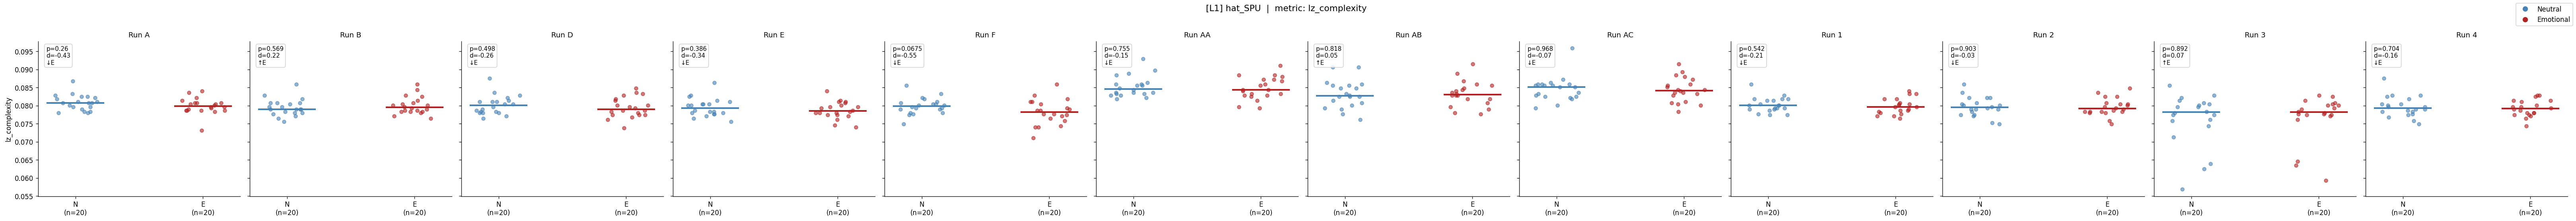


[L1] hat_MCE  —  best metric: lz_complexity  (combined p=0.1858)


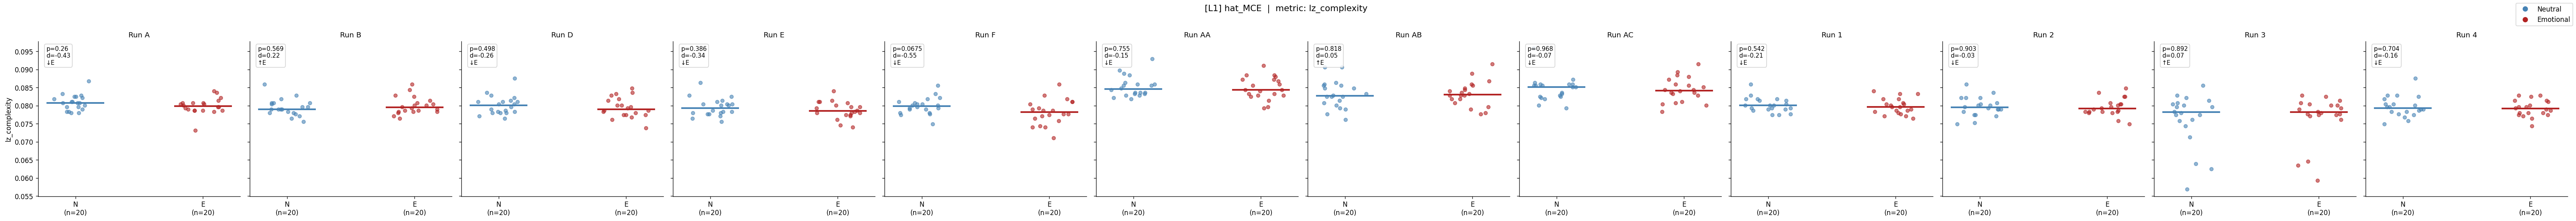


[L1] hat_TLB  —  best metric: mean_rate  (combined p=0.0593)


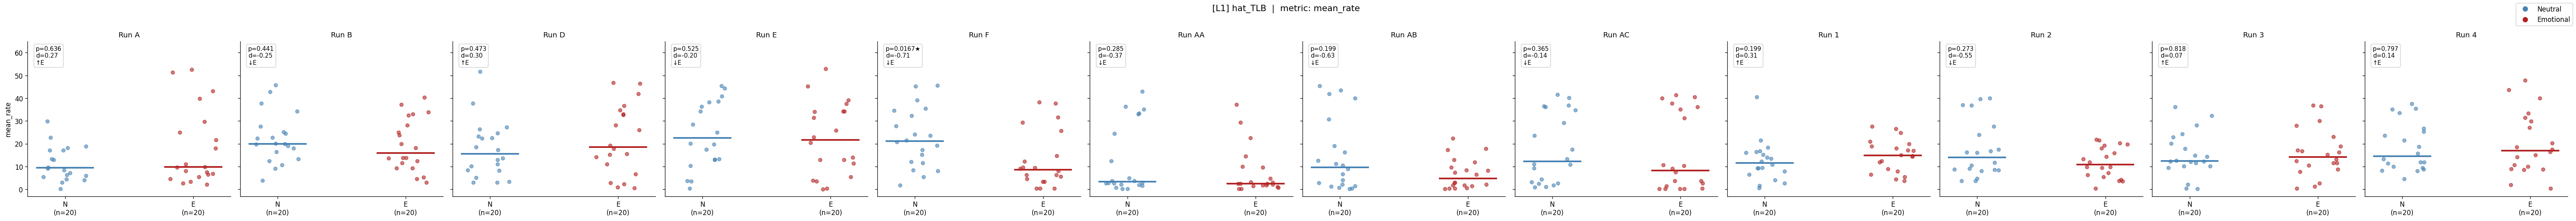


[L2] dTLB-load-misses  —  best metric: burst_clustering  (combined p=0.0550)


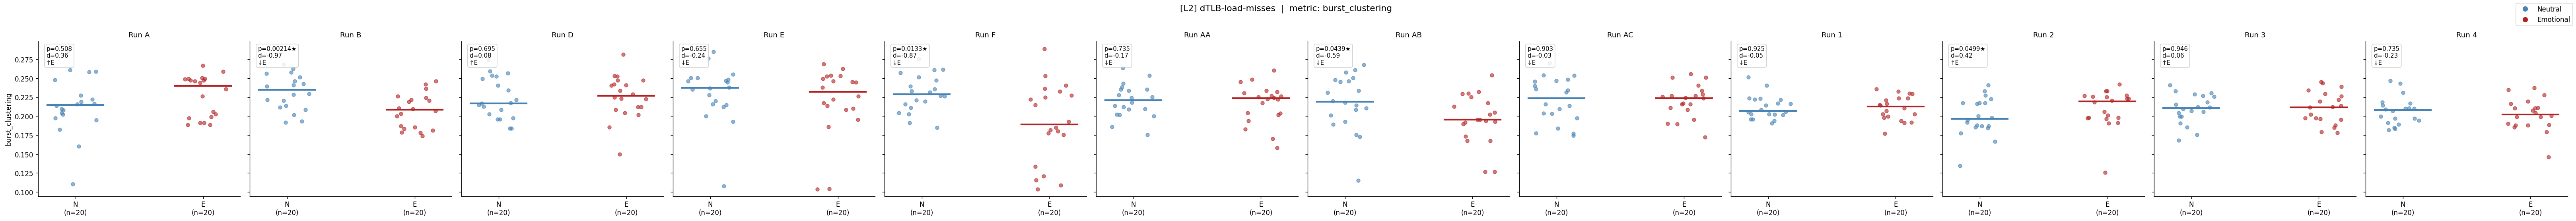


[L2] cache-misses  —  best metric: lz_complexity  (combined p=0.1601)


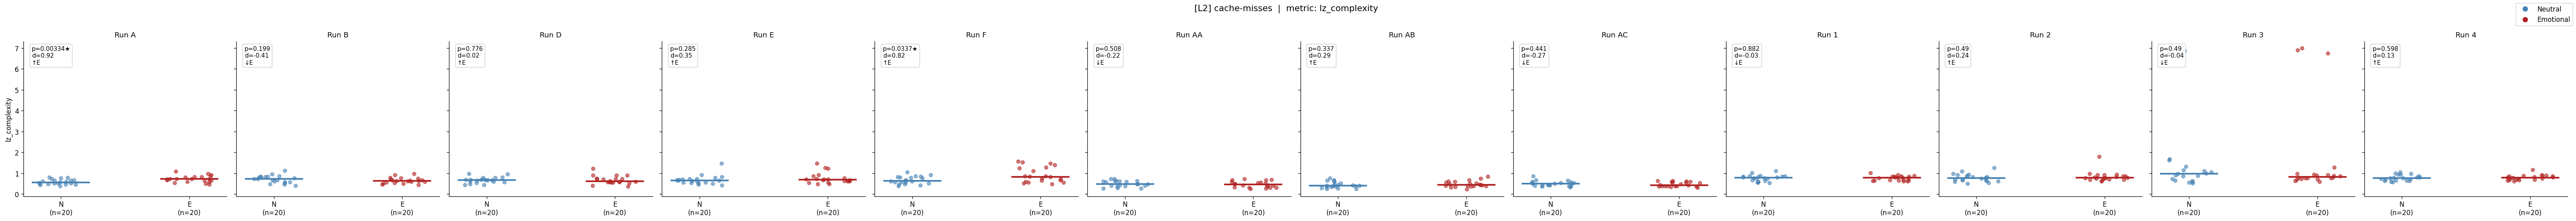


[L2] cache-references  —  best metric: perm_entropy  (combined p=0.0600)


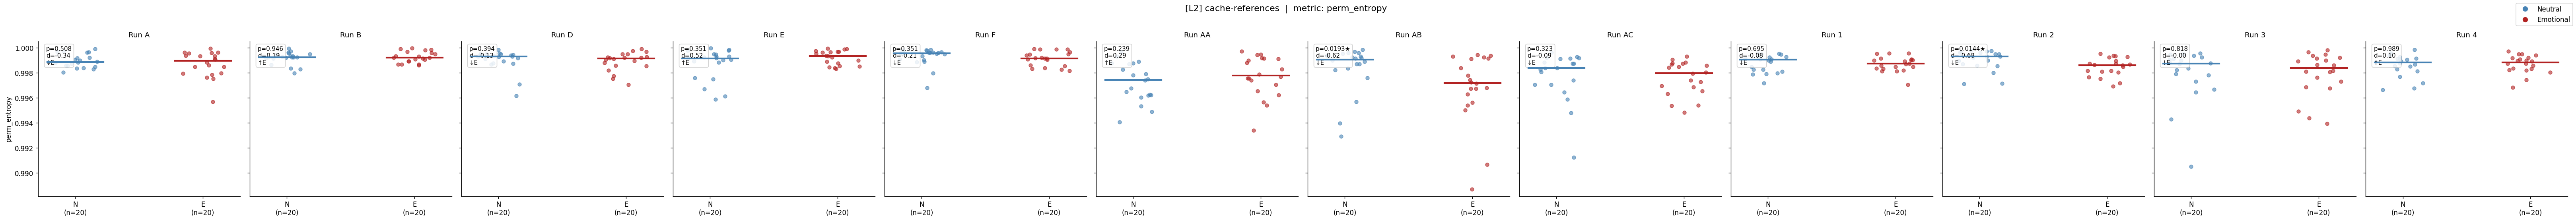

In [20]:
# ── Per-indicator strip plots: best metric, all runs as columns ───────────────
rng = np.random.default_rng(42)

for ind in ALL_FOCUS:
    layer = 'L1' if ind in HAT_L1 else 'L2'

    # Find best metric from combined analysis
    ind_rows = grid_df[(grid_df.indicator == ind) & (grid_df.status == 'ok')]
    if ind_rows.empty:
        print(f"[{layer}] {ind}: all metrics are zero or missing — skipping strip plots.")
        print()
        continue
    best_metric = ind_rows.loc[ind_rows.p.idxmin(), 'metric']
    best_p_comb = ind_rows.p.min()
    col = f"{ind}__{best_metric}"

    print(f"[{layer}] {ind}  —  best metric: {best_metric}  (combined p={best_p_comb:.4f})")

    fig, axes = plt.subplots(
        1, len(RUNS),
        figsize=(4.5 * len(RUNS), 4.5),
        sharey=True
    )
    for ax, run in zip(axes, RUNS):
        df_r  = dfs_by_run[run]
        n_vals = get_vals(df_r, col, 'neutral')
        e_vals = get_vals(df_r, col, 'emotional')

        if (pd.concat([n_vals, e_vals]).abs() < 1e-9).all():
            ax.text(0.5, 0.5, 'all zero', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='grey', style='italic')
            ax.set_title(f'Run {run}', fontsize=11)
            ax.set_xticks([])
            continue

        for x_pos, vals, color in [(0, n_vals.values, 'steelblue'),
                                    (1, e_vals.values, 'firebrick')]:
            jitter = rng.uniform(-0.18, 0.18, len(vals))
            ax.scatter(np.full(len(vals), x_pos) + jitter, vals,
                       color=color, alpha=0.6, s=28, zorder=3)
            ax.plot([x_pos-0.22, x_pos+0.22], [np.median(vals), np.median(vals)],
                    color=color, lw=2.5, zorder=4)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'N\n(n={len(n_vals)})', f'E\n(n={len(e_vals)})'], fontsize=10)
        ax.set_title(f'Run {run}', fontsize=11)
        ax.set_ylabel(best_metric if run == RUNS[0] else '', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)

        if len(n_vals) >= 3 and len(e_vals) >= 3:
            p, direction, d = mwu_stats(n_vals, e_vals)
            star = '★' if p < 0.05 else ''
            ax.text(0.04, 0.97, f'p={p:.3g}{star}\nd={d:.2f}\n{direction}',
                    transform=ax.transAxes, ha='left', va='top', fontsize=9,
                    bbox=dict(facecolor='white', alpha=0.85, edgecolor='#ccc', boxstyle='round'))

    handles = [plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=c, markersize=9, label=l)
               for c, l in [('steelblue', 'Neutral'), ('firebrick', 'Emotional')]]
    fig.legend(handles=handles, loc='upper right', fontsize=10)
    plt.suptitle(f'[{layer}] {ind}  |  metric: {best_metric}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    print()


### 5b-8 — hat_TLB: all 10 metrics compared

`hat_TLB` (TLB Shootdown IPI) is the one HAT Layer 1 indicator most likely to have
actual signal during LLM inference — the model's large weight tensors generate
VM pressure that can trigger TLB shootdowns.

We plot all 10 metrics for hat_TLB side by side using the combined dataset,
so we can see which aspect of the TLB shootdown pattern (rate, burstiness,
complexity, ...) differs most between conditions.

hat_TLB metric summary (all runs combined):
  All-zero metrics: none
  Metrics with signal: ['mean_rate', 'variance', 'p90_p10', 'slope', 'spectral_entropy', 'iat_cv', 'burst_rate', 'burst_clustering', 'lz_complexity', 'perm_entropy']



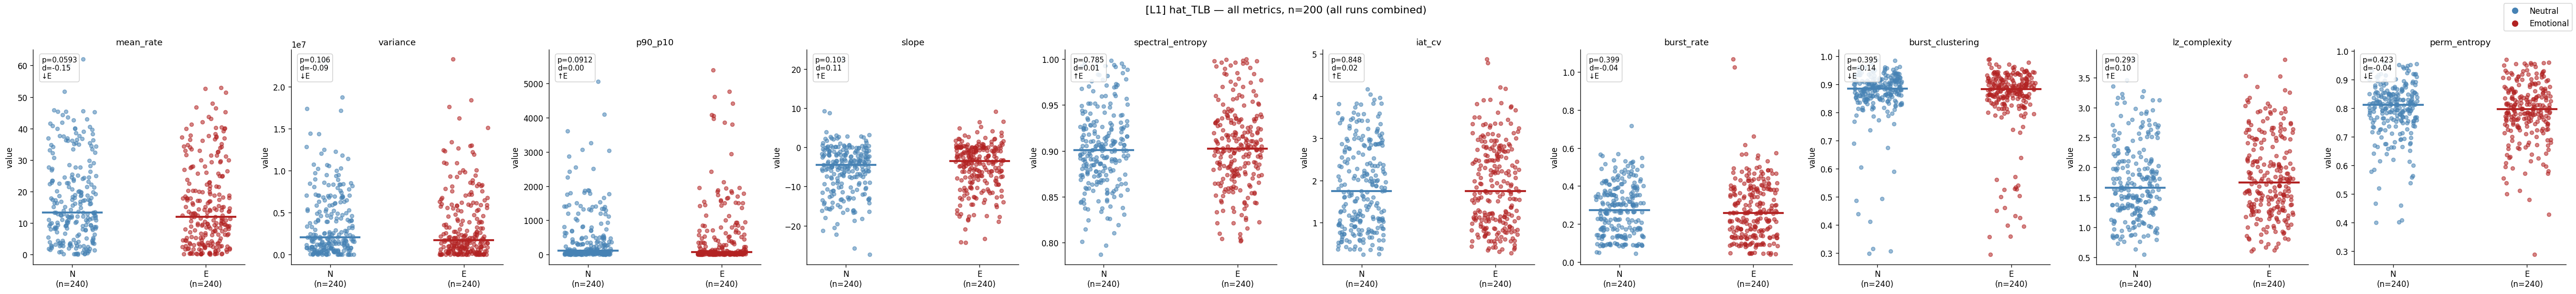

In [21]:
# ── hat_TLB: all metrics, combined dataset ────────────────────────────────────
ind = 'hat_TLB'
layer = 'L1'

tlb_rows = grid_df[grid_df.indicator == ind].copy()
all_zero_metrics = tlb_rows[tlb_rows.status == 'all_zero']['metric'].tolist()
ok_metrics       = tlb_rows[tlb_rows.status == 'ok']['metric'].tolist()

print(f"hat_TLB metric summary (all runs combined):")
print(f"  All-zero metrics: {all_zero_metrics if all_zero_metrics else 'none'}")
print(f"  Metrics with signal: {ok_metrics if ok_metrics else 'none'}")
print()

if not ok_metrics:
    print("hat_TLB is all-zero across all metrics and all runs.")
    print("This confirms the node is healthy — no TLB shootdown IPIs during inference.")
else:
    n_plots = len(ok_metrics)
    fig, axes = plt.subplots(1, n_plots, figsize=(4.5 * n_plots, 5), sharey=False)
    if n_plots == 1:
        axes = [axes]
    rng2 = np.random.default_rng(0)

    for ax, metric in zip(axes, ok_metrics):
        col    = f"{ind}__{metric}"
        n_vals = get_vals(df_all, col, 'neutral')
        e_vals = get_vals(df_all, col, 'emotional')
        p, direction, d = mwu_stats(n_vals, e_vals)

        for x_pos, vals, color in [(0, n_vals.values, 'steelblue'),
                                    (1, e_vals.values, 'firebrick')]:
            jitter = rng2.uniform(-0.18, 0.18, len(vals))
            ax.scatter(np.full(len(vals), x_pos) + jitter, vals,
                       color=color, alpha=0.55, s=22, zorder=3)
            ax.plot([x_pos-0.22, x_pos+0.22], [np.median(vals), np.median(vals)],
                    color=color, lw=2.5, zorder=4)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'N\n(n={len(n_vals)})', f'E\n(n={len(e_vals)})'], fontsize=10)
        ax.set_title(metric, fontsize=11)
        ax.set_ylabel('value', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)
        star = '★' if p < 0.05 else ''
        ax.text(0.04, 0.97, f'p={p:.3g}{star}\nd={d:.2f}\n{direction}',
                transform=ax.transAxes, ha='left', va='top', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='#ccc', boxstyle='round'))

    handles = [plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=c, markersize=9, label=l)
               for c, l in [('steelblue', 'Neutral'), ('firebrick', 'Emotional')]]
    fig.legend(handles=handles, loc='upper right', fontsize=10)
    plt.suptitle(f'[L1] hat_TLB — all metrics, n=200 (all runs combined)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


### 5b-9 — Cross-run consistency: which (indicator, metric) pairs are stable?

For each (indicator, metric) pair we summarise across all five runs:
- In how many runs does it have non-zero values?
- In how many runs is it significant (p < 0.05)?
- Is the direction (↑E / ↓E) consistent across runs?
- What is the best p-value seen in any single run?

This is the key table for the professor: it directly answers which
signals are reproducible vs run-specific flukes.

In [22]:
# ── Cross-run consistency summary ────────────────────────────────────────────
from collections import Counter

consistency_rows = []
for ind in ALL_FOCUS:
    layer = 'L1' if ind in HAT_L1 else 'L2'
    for metric in ALL_METRICS:
        col = f"{ind}__{metric}"
        run_results = []
        for run in RUNS:
            df_r = dfs_by_run[run]
            if col not in df_r.columns:
                continue
            n_vals = get_vals(df_r, col, 'neutral')
            e_vals = get_vals(df_r, col, 'emotional')
            if is_all_zero(df_r, col) or len(n_vals) < 3 or len(e_vals) < 3:
                run_results.append({'run': run, 'zero': True,
                                    'p': float('nan'), 'direction': '—'})
                continue
            p, direction, d = mwu_stats(n_vals, e_vals)
            run_results.append({'run': run, 'zero': False,
                                'p': p, 'direction': direction, 'd': d})

        n_nonzero  = sum(1 for r in run_results if not r['zero'])
        n_sig      = sum(1 for r in run_results if not r['zero']
                         and not pd.isna(r['p']) and r['p'] < 0.05)
        directions = [r['direction'] for r in run_results
                      if not r['zero'] and r['direction'] != '—']
        sign_cons  = len(set(directions)) == 1 if directions else False
        sign_mode  = directions[0] if sign_cons and directions else ('mixed' if directions else '—')
        ps         = [r['p'] for r in run_results if not r.get('zero') and not pd.isna(r['p'])]
        best_p     = min(ps) if ps else float('nan')

        consistency_rows.append({
            'indicator': ind, 'layer': layer, 'metric': metric,
            'n_nonzero': n_nonzero, 'n_sig': n_sig,
            'sign_mode': sign_mode, 'sign_consistent': sign_cons,
            'best_p': best_p,
        })

cons_df = pd.DataFrame(consistency_rows)

# Print: sort by n_sig desc, then best_p asc
print(f"{'Lyr':<4} {'Indicator':<28} {'Metric':<22} {'Non-zero':>8} "
      f"{'p<.05 runs':>10} {'Direction':>10} {'Best p':>10}")
print('-' * 100)

prev_ind = None
for _, r in cons_df.sort_values(['n_sig','best_p'], ascending=[False,True]).iterrows():
    if r['indicator'] != prev_ind:
        print()
        prev_ind = r['indicator']
    bp  = f"{r['best_p']:.4f}" if not pd.isna(r['best_p']) else '—'
    star = '★' if r['n_sig'] > 0 else ''
    cons_mark = '✓' if r['sign_consistent'] and r['n_sig'] > 1 else ''
    print(f"  {r['layer']:<3} {r['indicator']:<28} {r['metric']:<22} "
          f"{r['n_nonzero']:>8} {r['n_sig']:>10} "
          f"{r['sign_mode']:>10} {bp:>9}{star} {cons_mark}")

# Top consistent features
top_consistent = cons_df[
    (cons_df.n_sig >= 2) & (cons_df.sign_consistent)
].sort_values('best_p')

print(f"\n{'='*80}")
print(f"TOP CONSISTENT FEATURES: p<0.05 in ≥2 runs AND consistent direction")
print(f"{'='*80}")
if top_consistent.empty:
    print("  None found — no (indicator, metric) pair is significant in ≥2 runs")
    print("  with a consistent direction. This is expected at n=20+20 per run.")
else:
    for _, r in top_consistent.iterrows():
        print(f"  [{r['layer']}] {r['indicator']}__{r['metric']:<22} "
              f"sig in {r['n_sig']}/5 runs  dir={r['sign_mode']}  best p={r['best_p']:.4f}")


Lyr  Indicator                    Metric                 Non-zero p<.05 runs  Direction     Best p
----------------------------------------------------------------------------------------------------

  L2  dTLB-load-misses             burst_clustering             12          4      mixed    0.0021★ 

  L2  cache-misses                 lz_complexity                12          2      mixed    0.0033★ 

  L2  dTLB-load-misses             p90_p10                      12          2      mixed    0.0043★ 

  L2  cache-references             variance                     12          2      mixed    0.0071★ 

  L2  cache-misses                 slope                        12          2      mixed    0.0084★ 
  L2  cache-misses                 p90_p10                      12          2      mixed    0.0090★ 

  L2  cache-references             slope                        12          2      mixed    0.0106★ 
  L2  cache-references             burst_clustering             12          2      mixe

### 5b-10 — Final interpretation and summary for the professor

This cell prints a plain-language summary of the findings, structured
to directly address the professor's question about hardware anomalies.

In [23]:
# ── Final interpretation ──────────────────────────────────────────────────────
print("=" * 80)
print("SUMMARY FOR PROFESSOR — HAT Layer 1 vs Layer 2 analysis")
print("=" * 80)

l1_zero_inds = [ind for ind in HAT_L1
                if all(is_all_zero(df_all, f"{ind}__{m}")
                       for m in ALL_METRICS if f"{ind}__{m}" in df_all.columns)]
l1_signal_inds = [ind for ind in HAT_L1 if ind not in l1_zero_inds]

print()
print("1. HAT Layer 1 (genuine hardware anomaly interrupts):")
print(f"   Indicators examined: {HAT_L1}")
if l1_zero_inds:
    print(f"   All-zero (no events): {l1_zero_inds}")
    print("   → These indicators never fired across 200 trials (5 runs × 40 trials).")
    print("     This is the expected result for a healthy CloudLab node.")
if l1_signal_inds:
    print(f"   Has signal: {l1_signal_inds}")
    for ind in l1_signal_inds:
        ind_cons = cons_df[(cons_df.indicator == ind) & (cons_df.n_sig > 0)]
        if not ind_cons.empty:
            best = ind_cons.sort_values('best_p').iloc[0]
            print(f"   → {ind}: best metric={best['metric']}, "
                  f"significant in {best['n_sig']}/5 runs, "
                  f"direction={best['sign_mode']}, best p={best['best_p']:.4f}")

print()
print("2. HAT Layer 2 (continuous performance metrics — reference):")
for ind in HAT_L2_REF:
    ind_cons = cons_df[(cons_df.indicator == ind) & (cons_df.n_sig > 0)]
    if ind_cons.empty:
        print(f"   {ind}: no significant (indicator, metric) pairs across 5 runs")
    else:
        best = ind_cons.sort_values('best_p').iloc[0]
        print(f"   {ind}: best metric={best['metric']}, "
              f"significant in {best['n_sig']}/5 runs, "
              f"direction={best['sign_mode']}, best p={best['best_p']:.4f}")

print()
print("3. Key conclusion:")
if not l1_signal_inds:
    print("   HAT Layer 1 is entirely silent on this node (healthy hardware).")
    print("   The discrimination between neutral and emotional inference")
    print("   lives in Layer 2: continuous PMU metrics (cache misses, TLB misses)")
    print("   that deviate from their baseline patterns during emotional prompts.")
    print()
    print("   This is a valid and interpretable result:")
    print("   - It confirms no hardware anomaly events are triggered by either prompt type")
    print("   - It shifts focus to subtle behavioral differences in normal hardware counters")
    print("   - The Layer 2 signals are computation-coupled (cache, TLB) not OS noise")
else:
    print("   Some HAT Layer 1 events do fire and differ between conditions.")
    print("   This is scientifically interesting — see §5b-7 strip plots for details.")


SUMMARY FOR PROFESSOR — HAT Layer 1 vs Layer 2 analysis

1. HAT Layer 1 (genuine hardware anomaly interrupts):
   Indicators examined: ['hat_SPU', 'hat_MCE', 'hat_TLB']
   Has signal: ['hat_SPU', 'hat_MCE', 'hat_TLB']
   → hat_TLB: best metric=p90_p10, significant in 1/5 runs, direction=mixed, best p=0.0077

2. HAT Layer 2 (continuous performance metrics — reference):
   dTLB-load-misses: best metric=mean_rate, significant in 1/5 runs, direction=mixed, best p=0.0008
   cache-misses: best metric=spectral_entropy, significant in 1/5 runs, direction=mixed, best p=0.0007
   cache-references: best metric=spectral_entropy, significant in 1/5 runs, direction=mixed, best p=0.0004

3. Key conclusion:
   Some HAT Layer 1 events do fire and differ between conditions.
   This is scientifically interesting — see §5b-7 strip plots for details.
